<hr/>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">
[Tip]: To execute the Python code in the code cell below, click on the cell to select it and press <kbd>Shift</kbd> + <kbd>Enter</kbd>.
</div>
<hr/>

# Required Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from os.path import exists

sns.set_style("white")
sns.set_palette("coolwarm")


def load_polic_data():
    local = "police_project.csv"
   
    if exists(local):
        print ("Read from local file")
        return pd.read_csv(local)
    else:
        print ("Read from hu-box")        
        return pd.read_csv("https://box.hu-berlin.de/f/cc297480d22c42a6ae3e/?dl=1")


def load_data():
    df = load_polic_data()
    df.loc[df.stop_duration == '2', "stop_duration"] = '0-15 Min'
    df.loc[df.stop_duration == '1', "stop_duration"] = '0-15 Min'
    df.drop_duplicates(inplace=True)
    
    df.search_type = df.search_type.str.split(",")
    
    columns=["driver_gender", "driver_race", "violation", "stop_outcome", "stop_duration"]
    for col in columns:
        df[col] = df[col].astype("category")
    
    # Dropping the state and county name columns
    df.drop(["county_name","driver_age_raw"], axis='columns', inplace=True)
    
    # Dropping  the NaN in both gender and driver columns
    df.dropna(subset=["driver_gender","driver_race","driver_age"], inplace=True)
    
    new_date = df["stop_date"].str.cat(df["stop_time"], sep=" ")
    df['stop_datetime'] = pd.to_datetime(new_date)
    df.set_index("stop_datetime", inplace=True)
    
    df = df.convert_dtypes()
    
    return df

<hr> 

# Exercise 3: Bias and Fairness in Traffic Stops

### This notebook is split into ten tasks. You must solve at least 6 out of 10 tasks correctly.
    
1. Assess the impact of race, gender, and age on the frequency of police traffic stops.
2. Evaluate how gender influences police behavior during traffic stops.
3. Examine whether gender affects the likelihood of being frisked during a search.
4. Compare frisk rates during searches between males and females.
5. Compare frisk rates during searches between Black and White drivers.
6. Determine which gender is more likely to be arrested during a traffic stop.
7. Investigate the impact of driver age on the likelihood of being stopped.
8. Analyze whether stop duration influences the probability of an arrest.
9. Study how stop duration has changed over time to identify evolving policing practices.
10. Use a large language model to suggest additional insightful analyses of the dataset.

### You must hand in this exercise via Moodle.

## Dataset

This dataset contains records of traffic stops conducted by police officers across the United States from 2005 to 2015. It details the circumstances and outcomes of these stops. The data was sourced from the Stanford Open Policing Project, which collects and standardizes traffic stop data from law enforcement agencies nationwide. One of the project's main goals is to analyze and improve interactions between police and the public. The dataset encompasses stops made across all U.S. states during the specified period. It has 85845 rows × 13 columns.

<img src="https://images.pexels.com/photos/7715199/pexels-photo-7715199.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500">

In [ ]:
# DO NOT CHANGE THIS CODE
df = load_data()
df.head()

Read from local file


,stop_date,stop_time,driver_gender,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
stop_datetime,,,,,,,,,,,,,
2005-08-28 01:00:00,2005-08-28,01:00,M,26,White,Other Traffic Violation,Moving violation,True,"[Incident to Arrest, Protective Frisk]",Arrest Driver,True,16-30 Min,False
2005-10-01 00:00:00,2005-10-01,00:00,M,17,White,Equipment/Inspection Violation,Equipment,True,[Probable Cause],Arrest Driver,True,16-30 Min,True
2005-10-01 00:00:00,2005-10-01,00:00,M,17,White,Equipment/Inspection Violation,Equipment,True,[Probable Cause],Citation,False,30+ Min,True
2005-10-02 09:30:00,2005-10-02,09:30,M,30,White,Speeding,Speeding,True,[Incident to Arrest],Arrest Driver,True,30+ Min,False
2005-10-03 14:00:00,2005-10-03,14:00,M,27,Black,Equipment/Inspection Violation,Equipment,True,[Probable Cause],Citation,False,16-30 Min,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-12-07 18:45:00,2005-12-07,18:45,M,41,White,Speeding,Speeding,True,"[Probable Cause, Protective Frisk]",Citation,False,16-30 Min,False
2005-12-08 09:25:00,2005-12-08,09:25,M,21,White,Speeding,Speeding,True,[Probable Cause],Citation,False,16-30 Min,True
2005-12-08 21:15:00,2005-12-08,21:15,M,35,White,Registration Violation,Registration/plates,True,"[Incident to Arrest, Protective Frisk]",Arrest Driver,True,30+ Min,False


In [5]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 85845 entries, 2005-01-02 01:55:00 to 2015-12-31 22:46:00
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   stop_date           85845 non-null  string  
 1   stop_time           85845 non-null  string  
 2   driver_gender       85845 non-null  category
 3   driver_age          85845 non-null  Int64   
 4   driver_race         85845 non-null  category
 5   violation_raw       85845 non-null  string  
 6   violation           85845 non-null  category
 7   search_conducted    85845 non-null  boolean 
 8   search_type         3184 non-null   object  
 9   stop_outcome        85845 non-null  category
 10  is_arrested         85845 non-null  boolean 
 11  stop_duration       85845 non-null  category
 12  drugs_related_stop  85845 non-null  boolean 
dtypes: Int64(1), boolean(3), category(5), object(1), string(3)
memory usage: 4.9+ MB


In [6]:
df.describe(include=["string", "category"])

,stop_date,stop_time,driver_gender,driver_race,violation_raw,violation,stop_outcome,stop_duration
count,85845,85845,85845,85845,85845,85845,85845,85845
unique,3767,1432,2,5,12,6,6,3
top,2012-02-28,10:00,M,White,Speeding,Speeding,Citation,0-15 Min
freq,64,297,62446,61758,48217,48217,76592,69162


In [7]:
df.describe()

,driver_age
count,85845.0
mean,34.013291
std,12.73767
min,15.0
25%,23.0
50%,31.0
75%,43.0
max,99.0


### Some simple formatting inspirations for displaying percentages

In [8]:
# Compute percentage of genders
series = df["driver_gender"].value_counts().transform(lambda l: l / l.sum())

# Using '.style.format'
pd.DataFrame(series).style.format({'count': '{:.2%}'}).background_gradient(cmap='Blues')

,count
driver_gender,
M,72.74%
F,27.26%


In [9]:
# Compute ratio of driver race and gender while traffic stops
gender_race_ratio = pd.crosstab(df.driver_gender, df.driver_race, normalize=True)

# Format nicely
gender_race_ratio.style.format({
    'Asian': '{:.2%}', 'Black': '{:.2%}', 'Hispanic': '{:.2%}', 'Other': '{:.2%}', 'White': '{:.2%}'
}).background_gradient(cmap='Blues')

driver_race,Asian,Black,Hispanic,Other,White
driver_gender,,,,,
F,0.60%,2.99%,2.17%,0.03%,21.47%
M,2.02%,11.17%,8.83%,0.25%,50.47%


### Using a Countplot

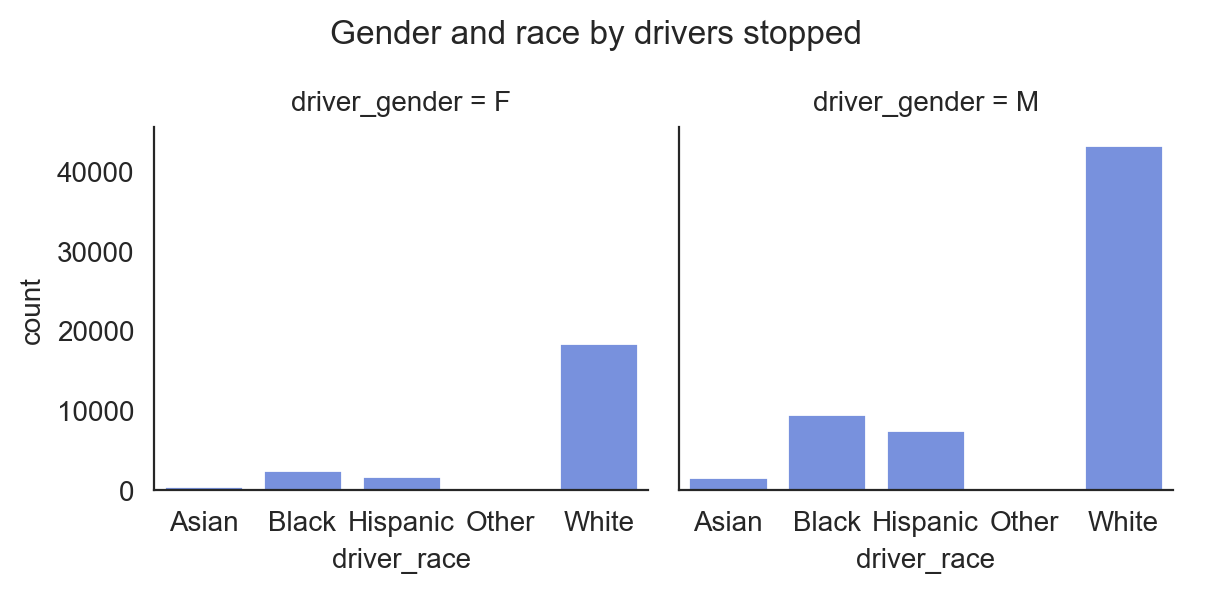

In [10]:
g = sns.catplot(
    data=df,
    x="driver_race", 
    col="driver_gender", 
    kind="count",
    height=3, aspect=1.,
)
g.fig.suptitle("Gender and race by drivers stopped")
g.fig.subplots_adjust(top=0.8)
plt.show()

# Exploratory Data Analysis


## Task 1 -  Assess the impact of race, gender, and age on the frequency of police traffic stops.

<div class="alert alert-block alert-success">
    
- Create three separate plots to visualize the distribution of traffic stops across the categories driver_gender, driver_age, and driver_race.
- Provide a brief description.


</div>

Read from local file


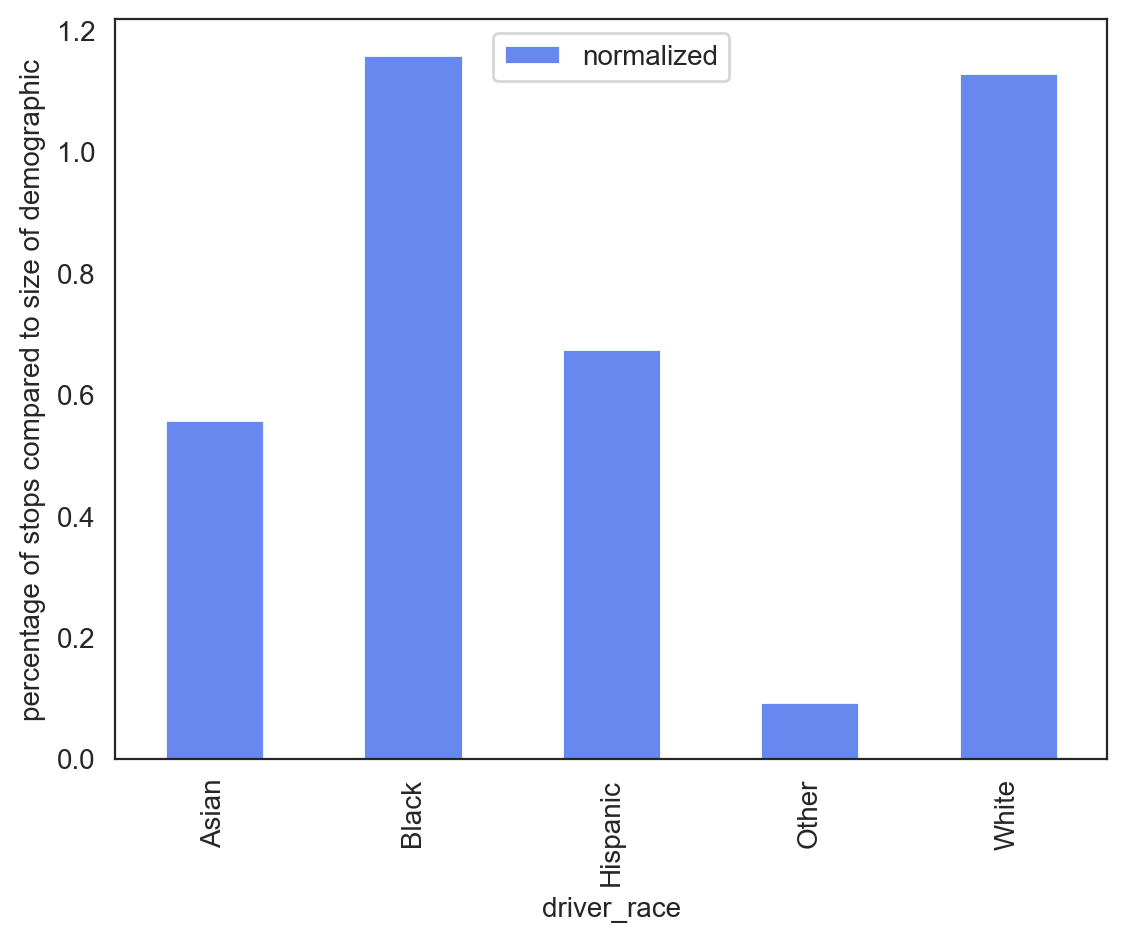

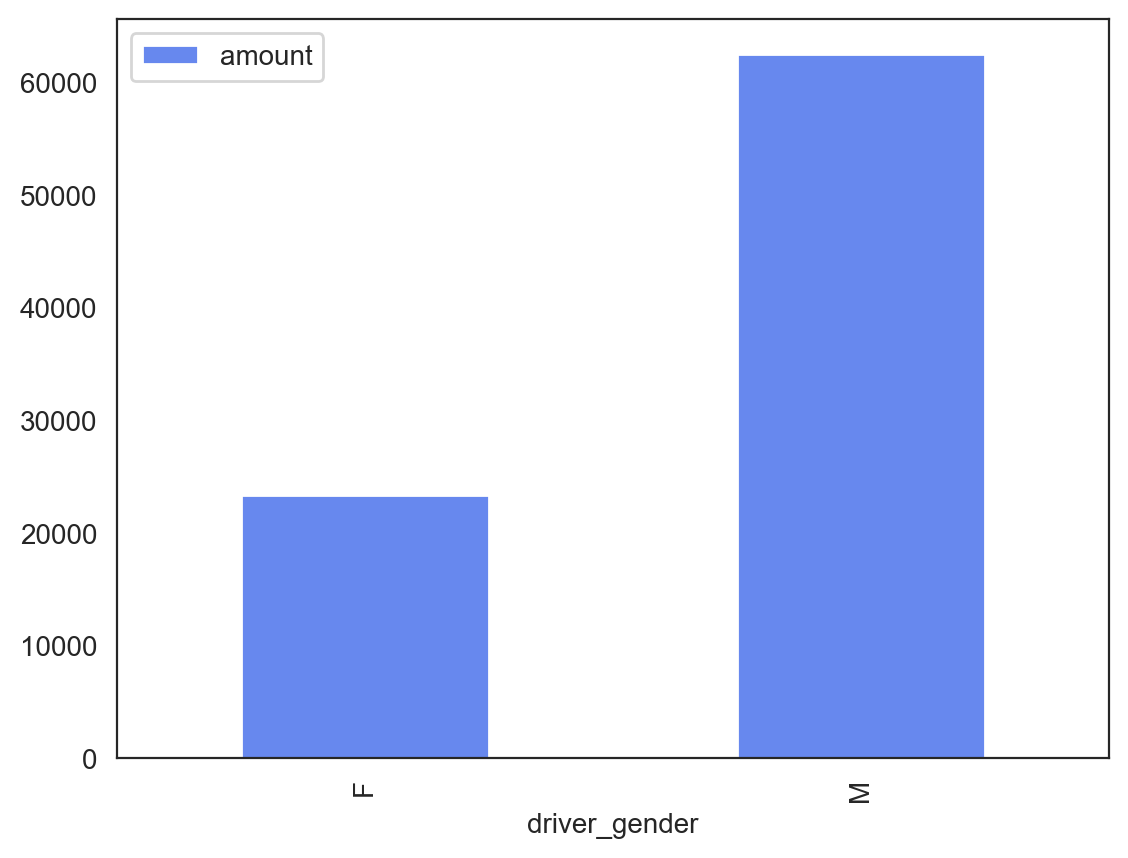

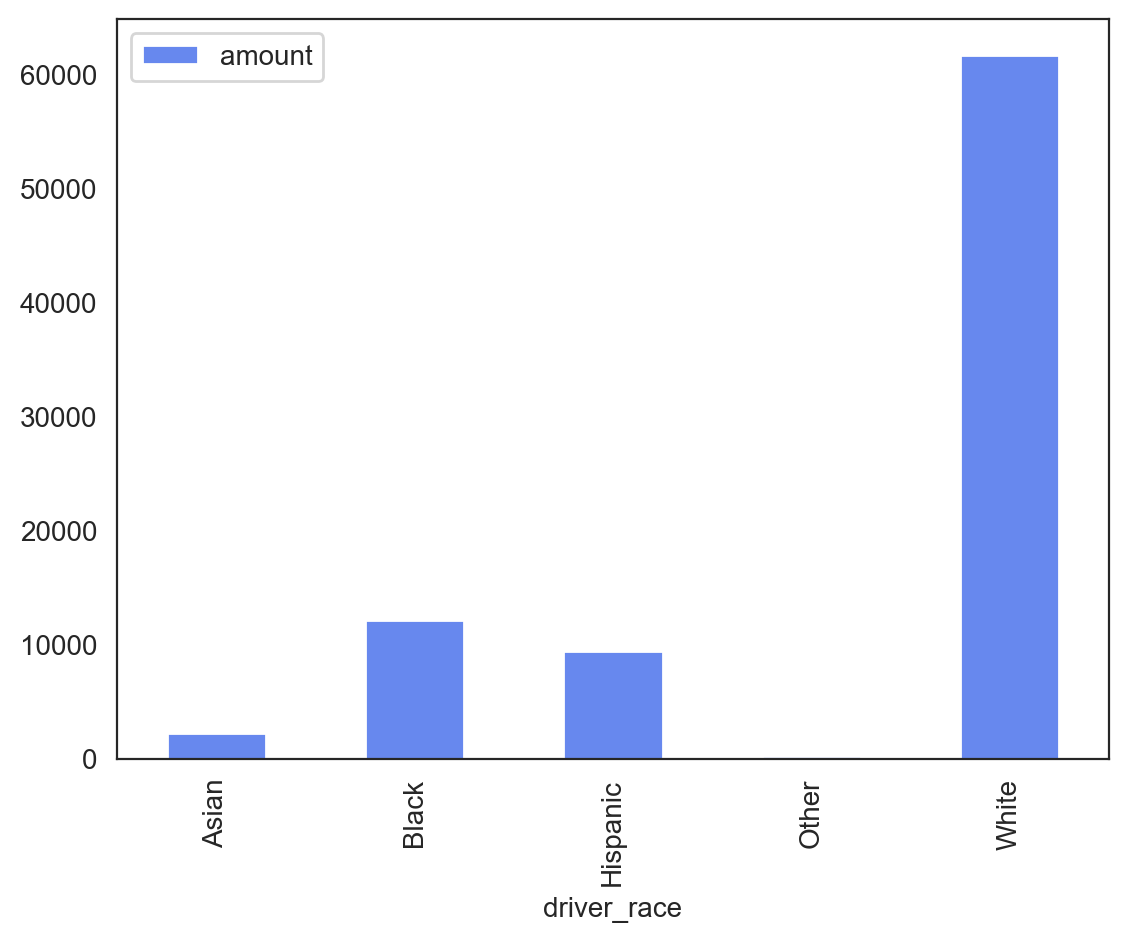

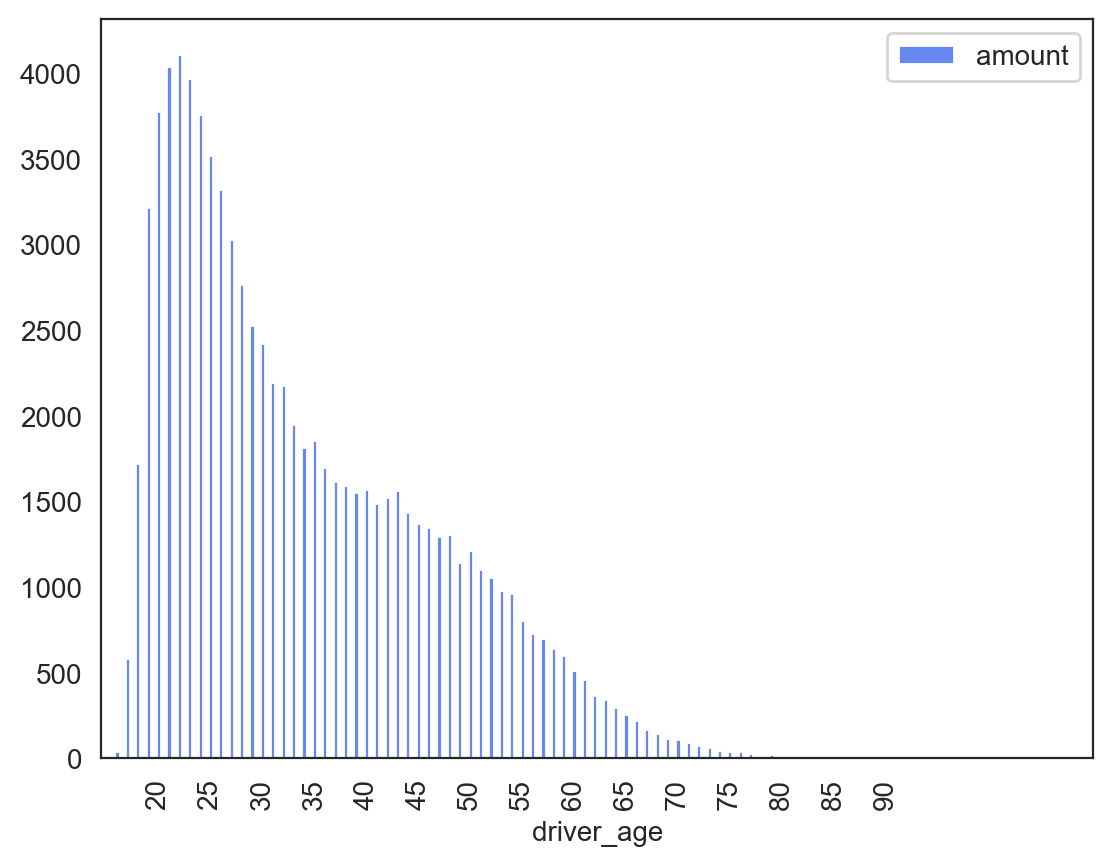

In [38]:
df = load_data()


#race gender and age distributions US 2010 census data:
male = 152000000 / (157000000 + 157000000)
female = 157000000 / (157000000 + 157000000)
under_18 = 0.24
ages_19_44 = 0.365
ages_45_65 = 0.264
ages_65_inf = 0.13
white = 0.637
black = 0.122
asian = 0.047
hispanic = 0.163
other = 0.03
# WRITE YOUR CODE HERE

q1 = df[["stop_date", "driver_race"]].groupby("driver_race").count().reset_index()
q1["relative"] = q1["stop_date"] / q1["stop_date"].sum()
q1["reference_rel"] = [asian, black, hispanic, other, white]
q1["normalized"] = q1["relative"] / q1["reference_rel"]
q1[["driver_race", "normalized"]].plot(kind = "bar", x="driver_race")
plt.ylabel("percentage of stops compared to size of demographic")

q1 = df[["driver_gender", "stop_date"]].groupby("driver_gender").count()
q1.columns = [ "amount"]
q1.plot(kind = "bar")

q1 = df[["driver_race", "stop_date"]].groupby("driver_race").count()
q1.columns = [ "amount"]
q1.plot(kind = "bar")

q1 = df[["driver_age", "stop_date"]].groupby("driver_age").count()
q1.columns = [ "amount"]
q1.plot(kind = "bar")

plt.xticks([i*5 for i in range(1, 20)]);


males get stopped almost 3 times as much as females;
white people are the vast majority of stops with black people being the distant second place;
The most amount of people stopped are under the age of 50 with the peak between 25 and 30

HOWEVER:
None of these values mean anything without knowing the distribution of these demographics in the population and especially on the road. I have one plot adjusted to the distribution of race within the USA population in 2010 and we can see that white and black people get stopped the same percentage. However to say anything about th amount of stops per race we would need to know the distribution of the different races on the road

## Task 2 - Evaluate how gender influences police behavior during traffic stops.

Speeding is the most common reason for traffic stops across genders. 

<div class="alert alert-block alert-success">

- Analyze how the driver’s gender influences the distribution of `stop_outcome` specifically for stops involving the violation type `speeding`.
- The analysis can be tabular or visual.
- Provide a brief description.


</div>

Tabular-Results should be similar to this:

| stop_outcome     |           F |           M |
|:-----------------|------------:|------------:|
| Arrest Driver    | 0.00170065  | 0.0103076   |
| Arrest Passenger | 0.000269614 | 0.000850323 |
| Citation         | 0.304892    | 0.644316    |
| N/D              | 0.000269614 | 0.000725885 |
| No Action        | 0.000145177 | 0.000725885 |
| Warning          | 0.012506    | 0.0232905   |

In [ ]:
df = load_data()

q2 = df[df.violation == "Speeding"]
q2 = q2[["stop_date", "stop_outcome", "driver_gender"]].groupby(["stop_outcome", "driver_gender"]).count().reset_index()
counts = df[["stop_date","driver_gender"]].groupby("driver_gender").count()["stop_date"].values

print(counts)

q2 = q2.pivot(columns="driver_gender", index = "stop_outcome", values = "stop_date")
q2["F"] = q2["F"] / counts[0]
q2["M"] = q2["M"] / counts[1]
q2



Read from local file
[23399 62446]


driver_gender,F,M
stop_outcome,,
Arrest Driver,0.003504,0.007959
Arrest Passenger,0.000556,0.000657
Citation,0.628275,0.497502
N/D,0.000556,0.000560
No Action,0.000299,0.000560
Warning,0.025770,0.017984


When female drivers get sptopped they get more citations and warnings and less "no actions", where men get arrested more.
 

## Task 3 - Examine whether gender affects the likelihood of being frisked during a search.

Protective frisk refers to a pat-down conducted by police during a vehicle search, typically to check for weapons.

<div class="alert alert-block alert-success">

- Analyze the *absolute frequency* of protective frisks (in `search_type`) by driver's gender.
- The analysis can be tabular or visual.
- Provide a brief description.

</div>

Tabular-Results should be similar to this:

| driver_gender   |   Protective Frisk |
|:----------------|-------------------:|
| F               |                 29 |
| M               |                241 |

In [71]:
df = load_data()
counts = df[["stop_date","driver_gender"]].groupby("driver_gender").count()["stop_date"].values

q3 = df.explode("search_type").dropna()
q3 = q3[q3.search_type == "Protective Frisk"]
q3 = q3[["stop_date", "driver_gender"]].groupby("driver_gender").count()
q3.columns = ["Protective Frisk"]
q3
# WRITE YOUR CODE HERE

Read from local file


,Protective Frisk
driver_gender,
F,29
M,241


Add your brief description

## Task 4 - Compare frisk rates during searches between males and females.

<div class="alert alert-block alert-success">

- Calculate the *relative frequency* of "Protective Frisk" (search_type) for each driver's gender.
- For this, *normalize* the count of frisks by the total number of search cases per gender.
- The analysis can be tabular or visual.
- Provide a brief description.

</div>

Tabular-Results should be similar to this:

| driver_gender   |    count |
|:----------------|---------:|
| M               | 0.385933 |
| F               | 0.123937 |

In [77]:
df = load_data()

counts = df[["stop_date","driver_gender"]].groupby("driver_gender").count()["stop_date"].values

q4 = df.explode("search_type").dropna()
q4 = q4[q4.search_type == "Protective Frisk"]
q4 = q4[["stop_date", "driver_gender"]].groupby("driver_gender").count()

q4["stop_date"][0] = q4["stop_date"][0] / counts[0]
q4["stop_date"][1] = q4["stop_date"][1] / counts[1]
q4.columns = ["count"]

q4


# WRITE YOUR CODE HERE

Read from local file


,count
driver_gender,
F,0.001239
M,0.003859


males have a much higher chance of getting frisked at a traffic stop than females

## Task 5 - Compare frisk rates during searches between Black and White drivers.

<div class="alert alert-block alert-success">

- Calculate the relative frequency of "Protective Frisk" (search_type) for each driver_race.
- Normalize the count of protective frisks by the total number of search cases within each race group.
- The analysis can be tabular or visual.
- Provide a brief description.

</div>

Tabular-Results should be similar to this:

| driver_race   |    count |
|:--------------|---------:|
| White         | 0.278506 |
| Black         | 0.485517 |
| Hispanic      | 0.370449 |
| Asian         | 0.177857 |
| Other         | 0        |

In [76]:
df = load_data()
counts = df[["stop_date","driver_race"]].groupby("driver_race").count()["stop_date"].values

q5 = df.explode("search_type").dropna()
q5 = q5[q5.search_type == "Protective Frisk"]
q5 = q5[["stop_date", "driver_race"]].groupby("driver_race").count()

for i in range(len(counts)):
    q5["stop_date"][i] = q5["stop_date"][i] / counts[i]
    
q5.columns = ["count"]

q5


# WRITE YOUR CODE HERE

Read from local file


,count
driver_race,
Asian,0.001779
Black,0.004855
Hispanic,0.003704
Other,0.000000
White,0.002785


Black people get frisked twice as much as white people

## Task 6 - Determine which gender is more likely to be arrested during a traffic stop.

<div class="alert alert-block alert-success">

- Analyze the effect of driver gender on arrest likelihood (`is_arrested`).
- The analysis can be tabular or visual.
- Provide a brief description.

</div>

Tabular-Results should be similar to this:
| driver_race   |   is_arrested |
|:--------------|--------------:|
| Asian         |    0.0182303  |
| Black         |    0.0571922  |
| Hispanic      |    0.0590601  |
| Other         |    0.00840336 |
| White         |    0.0258266  |

In [86]:
df = load_data()

counts = df[["stop_date","driver_gender"]].groupby("driver_gender").count()["stop_date"].values

q4 = df[df.is_arrested == True]
q4 = q4[["stop_date", "driver_gender"]].groupby("driver_gender").count()

q4["stop_date"][0] = q4["stop_date"][0] / counts[0]
q4["stop_date"][1] = q4["stop_date"][1] / counts[1]
q4.columns = ["count"]

q4

# WRITE YOUR CODE HERE

Read from local file


,count
driver_gender,
F,0.025087
M,0.036896


Men get arrested twice as much but that does not say anything about the likelyhood of an arrest for the same crime. It can also just mean that men cause more serious crimes when they cause anything

## Task 7 - Investigate the impact of driver age on the likelihood of being stopped.

<div class="alert alert-block alert-success">

- Visualize the distribution of driver ages in the dataset. 
- Provide a brief description.
    
</div>

Read from local file


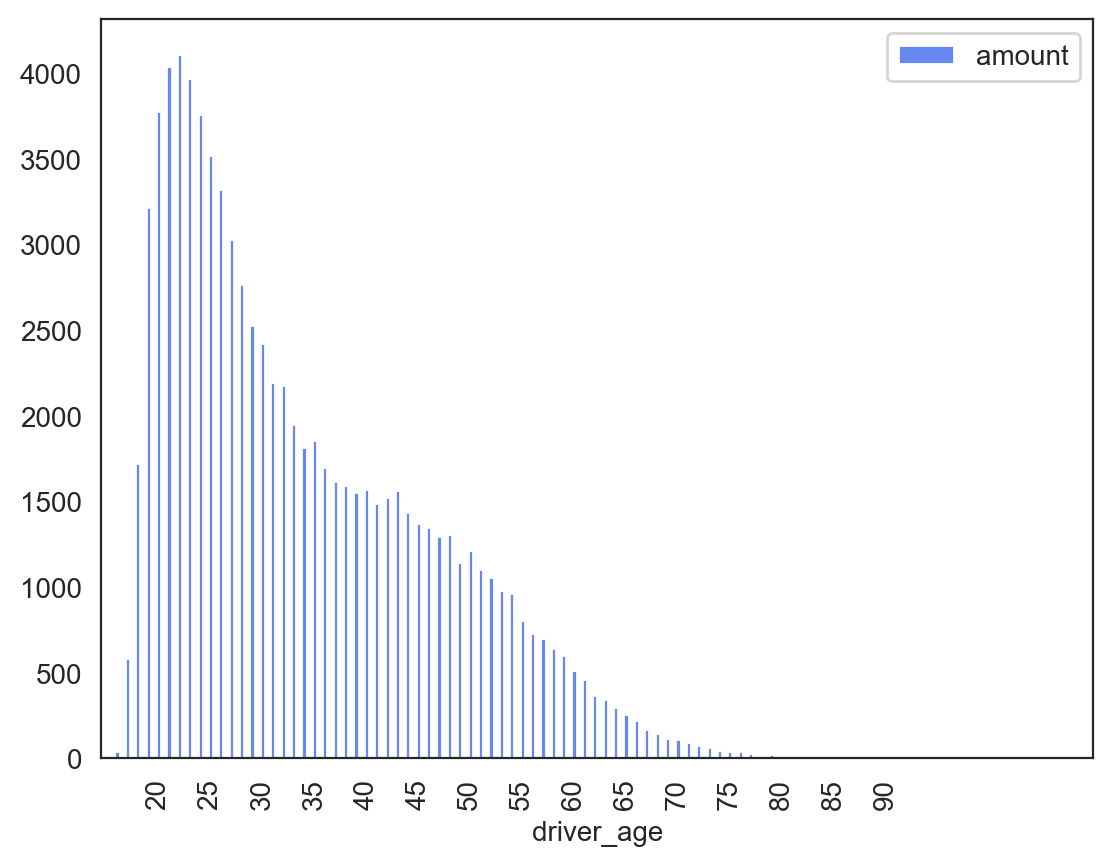

In [87]:
df = load_data()

q1 = df[["driver_age", "stop_date"]].groupby("driver_age").count()
q1.columns = [ "amount"]
q1.plot(kind = "bar")

plt.xticks([i*5 for i in range(1, 20)]);

The most amount of people stopped are under the age of 50 with the peak between 25 and 30

## Task 8 - Analyze whether stop duration influences the probability of an arrest.

<div class="alert alert-block alert-success">

- Analyze how the duration of traffic stops influences the likelihood of an arrest.

- The analysis can be tabular or visual.

- Provide a brief description.
    
</div>

In case of Tabular-Results, it should be similar to this:

| stop_duration   |   is_arrested |
|:----------------|--------------:|
| 0-15 Min        |     0.0123334 |
| 16-30 Min       |     0.0911045 |
| 30+ Min         |     0.253367  |

In [112]:
df = load_data()
counts = df[["stop_date","stop_duration"]].groupby("stop_duration").count()["stop_date"].values

df['is_arrested'] = df['is_arrested'].astype(int)

# Group by stop_duration and calculate arrest probability
q8 =df.groupby('stop_duration')['is_arrested'].mean().reset_index()
q8
# WRITE YOUR CODE HERE

Read from local file


,stop_duration,is_arrested
0,0-15 Min,0.012333
1,16-30 Min,0.091105
2,30+ Min,0.253367


30+ min is by far the most common stop duration

## Task 9 -  Study how stop duration has changed over time to identify evolving policing practices.

<div class="alert alert-block alert-success">

- Visualize how stop duration changes over time.
- Provide a brief description.

</div>


Read from local file


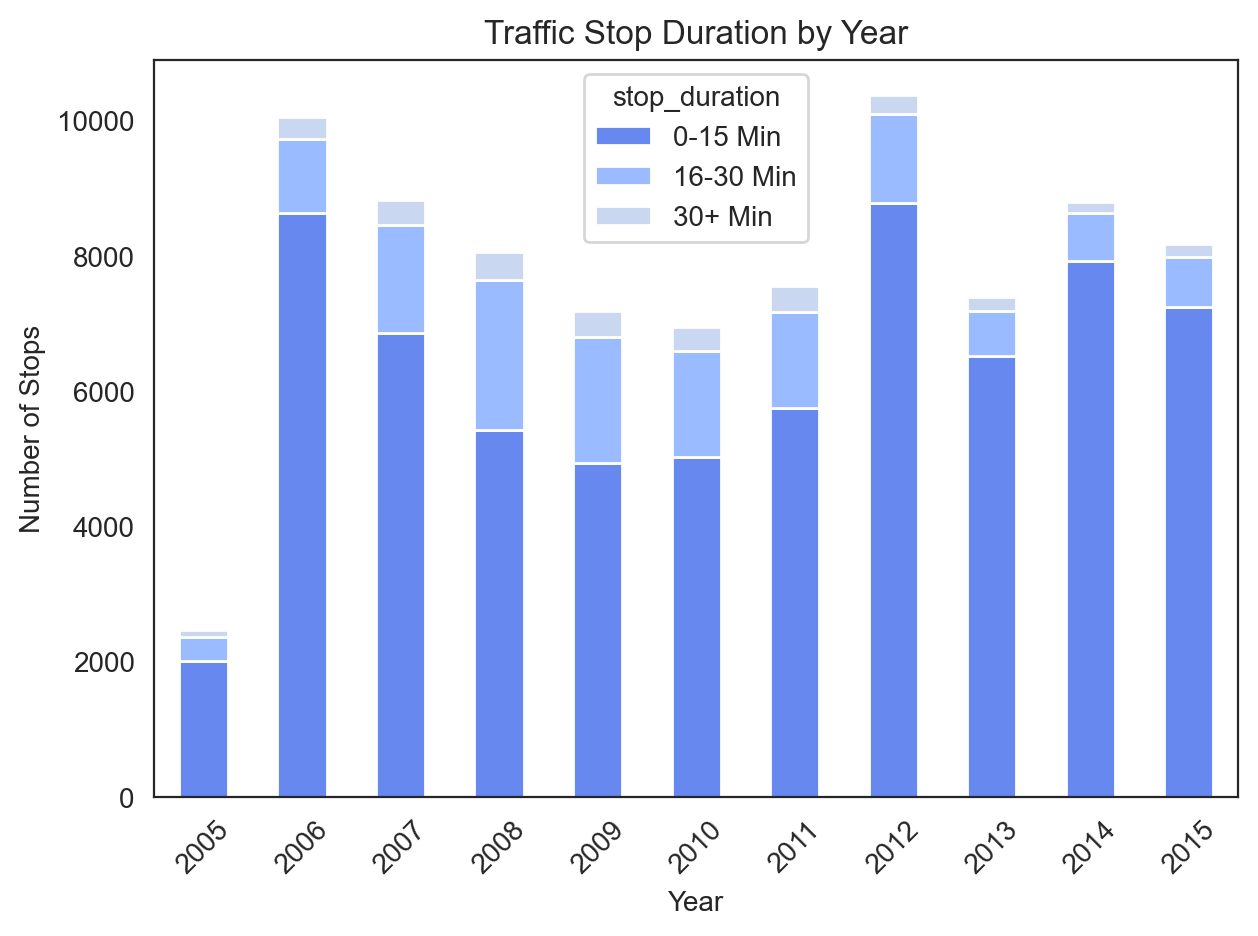

In [122]:
df = load_data()
df["year"] = df["stop_date"].str[:4]

df = df[["stop_date", "stop_duration", "year"]].groupby(["year", "stop_duration"]).count()

df = df.rename(columns={"stop_date": "count"})

# Convert MultiIndex to columns
df = df.reset_index()

# Pivot for plotting
pivot_df = df.pivot(index="year", columns="stop_duration", values="count")

# Plot stacked bar chart
pivot_df.plot(kind="bar", stacked=True)

plt.xlabel("Year")
plt.ylabel("Number of Stops")
plt.title("Traffic Stop Duration by Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WRITE YOUR CODE HERE

after 2005 the amount of stops significantly increased and after 2012 the stops became longer on average

## Task 10 - Use a large language model to suggest additional insightful analyses of the dataset.

<div class="alert alert-block alert-success">

- Request additional analysis suggestions from a large language model (LLM).
- Select one suggested analysis and perform it.
- Provide a brief description.
    
</div>

In [ ]:
# Use ChatGPT...

Add your brief description

<hr> 

# Submit two-fold via Moodle:
- Your notebook 
- A html export of this notebook

### You must hand in this exercise via moodle